In [20]:
import pandas as pd
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from itertools import combinations
from sklearn.base import clone
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier

In [21]:
df_wine = pd.read_csv(
'https://archive.ics.uci.edu/ml/'
'machine-learning-databases/wine/wine.data',
header=None
)
df_wine.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
dtype: int64

In [22]:
df_wine.shape

(178, 14)

It's great that we don't have null values but i will preform imputing bothways, it will cost us nothing and there's no benefit but it's a way for me to memorize

In [23]:
imr = SimpleImputer(missing_values=np.nan , strategy='mean') # we could also used something like mode
imr_after = imr.fit(df_wine.values) # notice df.values to convert from pandas to numpy array
imputed_data = imr_after.transform(df_wine.values) # Here we transform the data
imputed_data

array([[1.000e+00, 1.423e+01, 1.710e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.000e+00, 1.320e+01, 1.780e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.000e+00, 1.316e+01, 2.360e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [3.000e+00, 1.327e+01, 4.280e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [3.000e+00, 1.317e+01, 2.590e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [3.000e+00, 1.413e+01, 4.100e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 14))

As we saw there's no difference in shape because there's no minimization of data also we could alternativly of using SimpleImputer we could've used pandas

In [24]:
df_wine.fillna(df_wine.mean)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [25]:
df = pd.DataFrame([
['green', 'M', 10.1, 'class2'],

['red', 'L', 13.5, 'class1'],
['blue', 'XL', 15.3, 'class2']])
df.columns = ['color', 'size', 'price', 'classlabel']
df

,color,size,price,classlabel
0,green,M,10.1,class2
1,red,L,13.5,class1
2,blue,XL,15.3,class2


In [26]:
class_mapping = {label: idx for idx, label in enumerate(np.unique(df['classlabel']))}
class_mapping

{'class1': 0, 'class2': 1}

In [27]:
df['classlabel'] = df['classlabel'].map(class_mapping)
df

,color,size,price,classlabel
0,green,M,10.1,1
1,red,L,13.5,0
2,blue,XL,15.3,1


In [28]:
inv_class_mapping = {k: v for v, k in class_mapping.items()}

df['classlabel'] = df['classlabel'].map(inv_class_mapping)
df

,color,size,price,classlabel
0,green,M,10.1,class2
1,red,L,13.5,class1
2,blue,XL,15.3,class2


In [29]:
df_wine_imputed = pd.DataFrame(imputed_data, columns=df_wine.columns, index=df_wine.index)
X, y = df_wine_imputed.iloc[:, 1:].values, df_wine_imputed.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.fit_transform(X_test)
df_wine_imputed

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,1.0,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,1.0,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,1.0,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,1.0,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3.0,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,3.0,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,3.0,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,3.0,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [30]:
lr = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', multi_class='ovr')

lr.fit(X_train_std, y_train)
print("Training Accuracy: ", lr.score(X_train_std, y_train))

print("Training Accuracy: ", lr.score(X_test_std, y_test))


Training Accuracy:  1.0
Training Accuracy:  1.0


d:\Projects\Learning-ML-Hands-On\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
d:\Projects\Learning-ML-Hands-On\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


In [31]:
lr.intercept_

array([-1.26340887, -1.21579286, -2.37188986])

In [32]:
lr.coef_

array([[ 1.24529025,  0.18070612,  0.74228239, -1.15963565,  0.        ,
         0.        ,  1.17687366,  0.        ,  0.        ,  0.        ,
         0.        ,  0.53953466,  2.51152014],
       [-1.53740351, -0.38699864, -0.99514337,  0.36464893, -0.05954042,
         0.        ,  0.66796066,  0.        ,  0.        , -1.93401642,
         1.23424859,  0.        , -2.23201533],
       [ 0.13546617,  0.16951002,  0.35773887,  0.        ,  0.        ,
         0.        , -2.43416678,  0.        ,  0.        ,  1.561855  ,
        -0.81713866, -0.49767172,  0.        ]])

Now I will implement SBS (Sequential Backward Selection) from scratch

In [33]:
class SBS:
    def __init__(self, estimator, k_feature, scoring=accuracy_score, test_size=0.25, random_state=1):
        self.estimator = clone(estimator)
        self.scoring = scoring
        self.k_feature = k_feature
        self.test_size = test_size
        self.random_state = random_state
    def fit(self, X, y):
        X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=self.random_state, test_size=self.test_size)
        
        dim = X_train.shape[1]
        self.indices_ = tuple(range(dim))
        self.subset_ = [self.indices_]

        score = self._calc_score(X_train, X_test, y_train, y_test, self.indices_)

        self.score_ = [score]

        while dim > self.k_feature:
            subset = []
            scores = []

            for p in combinations(self.indices_, r=dim - 1):
                score = self._calc_score(X_train, X_test, y_train, y_test, p)
                scores.append(score)
                subset.append(p)
            
            best = np.argmax(scores)
            self.indices_ = subset[best]
            self.subset_.append(self.indices_)
            dim -= 1
            self.score_.append(scores[best])

        self.k_feature = self.subset_[-1]
        return self


    def transform(self, X):
        return X[:, self.indices_]

    def _calc_score(self, X_train, X_test, y_train, y_test, indices):
        self.estimator.fit(X_train[:, indices], y_train)
        predict = self.estimator.predict(X_test[:, indices])
        score = self.scoring(y_test, predict)
        return score

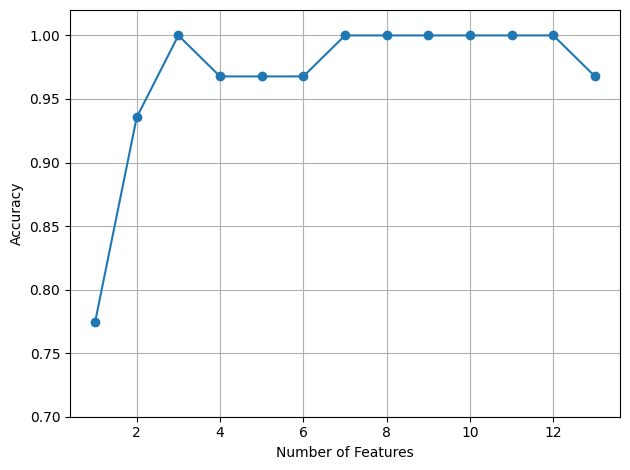

In [36]:
knn = KNeighborsClassifier(n_neighbors=5)
sbs = SBS(knn, k_feature=1)
sbs.fit(X_train_std, y_train)
k = [len(k) for k in sbs.subset_]
plt.plot(k, sbs.score_, marker='o')
plt.ylim(0.7, 1.02)
plt.ylabel("Accuracy")
plt.xlabel("Number of Features")
plt.grid()
plt.tight_layout()
plt.show()